# Metodología SEMMA – Dataset Pediátrico 2024
**Predicción de Riesgo Cardiovascular en Pacientes Pediátricos**

Metodología empleada: **SEMMA** (Sample → Explore → Modify → Model → Assess)



---
## ⚙️ Configuración Global e Importaciones

In [ ]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, io, os, warnings, joblib

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
CV_FOLDS     = 5

# ── Rangos clínicamente válidos para pacientes pediátricos ────────────────────
# CORRECCIÓN: usados para eliminar outliers imposibles antes del split
RANGOS_VALIDOS = {
    'edad':                (6,   17),
    'peso_kg':             (5,  120),
    'pa_sistolica':        (60, 160),
    'frecuencia_cardiaca': (40, 200),
    'colesterol_mgdl':     (50, 350),
}

COLORES_MODELO = {
    'Logistic Regression':  'steelblue',
    'Decision Tree':        'darkorange',
    'Random Forest':        'seagreen',
    'Gradient Boosting':    'purple',
    'K-Nearest Neighbors':  'indianred',
}

sns.set_style('whitegrid')
print('✅ Librerías cargadas y configuración global establecida.')
print(f'   RANDOM_STATE = {RANDOM_STATE} | TEST_SIZE = {TEST_SIZE} | CV_FOLDS = {CV_FOLDS}')


✅ Librerías cargadas y configuración global establecida.
   RANDOM_STATE = 42 | TEST_SIZE = 0.2 | CV_FOLDS = 5


---
## 🔹 FASE 1 – SAMPLE

La fase de muestreo comprende tres pasos secuenciales:
1. **Carga del dataset** desde Google Drive con manejo de errores
2. **Normalización de nombres** y conversión de tipos de dato *antes* del split
3. **Eliminación de outliers** clínicamente imposibles
4. **División estratificada** train / test (80 / 20)

### 1.1 – Carga del dataset

In [ ]:
FILE_ID      = "1x9wbU-hK7oRmnspe-UHA5nmTGWkd_Z4x"
URL_DESCARGA = f'https://drive.google.com/uc?export=download&id={FILE_ID}'

print("⏳ Descargando dataset desde Google Drive...")
try:
    response = requests.get(URL_DESCARGA)
    response.raise_for_status()
    try:
        df_raw = pd.read_csv(io.BytesIO(response.content))
        data_path = "Google Drive (CSV)"
    except Exception:
        df_raw = pd.read_excel(io.BytesIO(response.content))
        data_path = "Google Drive (Excel)"
    print(f"✅ Archivo cargado: {data_path}")
except Exception as e:
    raise FileNotFoundError(f"❌ No se pudo descargar el archivo: {e}")

print(f"Dimensiones (raw): {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print("Columnas (raw):", df_raw.columns.tolist())


⏳ Descargando dataset desde Google Drive...
✅ Archivo cargado: Google Drive (CSV)
Dimensiones (raw): 5000 filas × 7 columnas
Columnas (raw): ['EDAD', ' genero', 'Peso_kg', 'PA_Sistolica', 'frecuencia_Cardiaca', 'Colesterol_mgdl', 'RIESGO']


### 1.2 – Normalización de nombres de columnas

In [ ]:
# Reconstruir si viene en una sola columna con comas (caso especial)
if df_raw.shape[1] == 1 and "," in str(df_raw.columns[0]):
    col_unica = df_raw.columns[0]
    cols = [c.strip() for c in str(col_unica).split(",")]
    df_raw = df_raw[col_unica].astype(str).str.split(",", expand=True)
    df_raw.columns = cols
    print("✅ Dataset reconstruido desde columna única.")

# Estandarizar nombres: minúsculas, sin espacios
df_raw.columns = (df_raw.columns.astype(str).str.strip()
                  .str.lower().str.replace(" ", "_"))

# Mapa de variantes conocidas
rename_map = {
    "edadd": "edad", "age": "edad",
    "_genero": "genero", "sexo": "genero", "gender": "genero",
    "peso": "peso_kg",
    "pasistolica": "pa_sistolica", "presion_sistolica": "pa_sistolica",
    "frecuencia_cardiaca_": "frecuencia_cardiaca",
    "colesterol": "colesterol_mgdl",
    "riesgo": "riesgo_cv", "riesgo__cv": "riesgo_cv",
}
df_raw = df_raw.rename(columns={c: rename_map.get(c, c) for c in df_raw.columns})

REQUIRED_COLS = ["edad","genero","peso_kg","pa_sistolica",
                 "frecuencia_cardiaca","colesterol_mgdl","riesgo_cv"]
missing = [c for c in REQUIRED_COLS if c not in df_raw.columns]
if missing:
    raise ValueError(f"❌ Faltan columnas requeridas: {missing}")
print("✅ Todas las columnas requeridas están presentes.")
print(df_raw.head())


✅ Todas las columnas requeridas están presentes.
   edad  genero  peso_kg pa_sistolica  frecuencia_cardiaca  colesterol_mgdl  \
0    12    Masc     42.4        109,0                 80.0            161.0   
1     9     FEM     34.3        102,0                 80.0            149.0   
2    16       f     62.2        116,0                 74.0            169.0   
3    13   masc      45.7         92,0                 73.0            172.0   
4    10   masc      35.3        112,0                 83.0            141.0   

   riesgo_cv  
0          0  
1          0  
2          1  
3          0  
4          0  


### 1.3 – Conversión de tipos de dato antes del split

In [ ]:
def limpiar_genero(val):
    """Estandariza genero a 0 (femenino) / 1 (masculino)."""
    if pd.isna(val): return np.nan
    v = str(val).strip().lower()
    if v in ("masculino","m","masc","male","h","hombre"): return 1
    if v in ("femenino","f","fem","female","mujer"): return 0
    try:
        iv = int(float(v))
        if iv in (0,1): return iv
    except Exception: pass
    return np.nan

def limpiar_pa(val):
    """Convierte pa_sistolica con coma decimal ('109,0') a float."""
    if pd.isna(val): return np.nan
    try: return float(str(val).strip().replace(",","."))
    except Exception: return np.nan

df_raw["genero"]       = df_raw["genero"].apply(limpiar_genero)
df_raw["pa_sistolica"]  = df_raw["pa_sistolica"].apply(limpiar_pa)

for col in ["edad","peso_kg","frecuencia_cardiaca",
            "colesterol_mgdl","pa_sistolica","genero","riesgo_cv"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print("Tipos de datos tras conversión:")
print(df_raw.dtypes)
print(f"\nNulos por columna:\n{df_raw.isnull().sum()}")


Tipos de datos tras conversión:
edad                     int64
genero                   int64
peso_kg                float64
pa_sistolica           float64
frecuencia_cardiaca    float64
colesterol_mgdl        float64
riesgo_cv                int64
dtype: object

Nulos por columna:
edad                     0
genero                   0
peso_kg                150
pa_sistolica             0
frecuencia_cardiaca      0
colesterol_mgdl        100
riesgo_cv                0
dtype: int64


In [ ]:
df_raw.describe()

,edad,genero,peso_kg,pa_sistolica,frecuencia_cardiaca,colesterol_mgdl,riesgo_cv
count,5000.00000,5000.000000,4850.000000,5000.000000,5000.000000,4900.000000,5000.000000
mean,11.47100,0.494200,43.566742,111.541600,82.198000,159.767755,0.220000
std,4.05912,0.500016,12.305285,10.095616,8.450224,24.752087,0.414288
min,6.00000,0.000000,0.800000,76.000000,53.000000,64.000000,0.000000
25%,8.00000,0.000000,33.800000,104.000000,76.000000,143.000000,0.000000
50%,11.00000,0.000000,43.300000,112.000000,82.000000,160.000000,0.000000
75%,14.00000,1.000000,53.200000,119.000000,88.000000,177.000000,0.000000
max,160.00000,1.000000,76.400000,147.000000,115.000000,250.000000,1.000000


### 1.4 – Eliminación de outliers clínicamente imposibles

> **Corrección crítica:** el método `describe()` muestra
> `edad_max = 160` y `peso_min = 0.8 kg`, valores imposibles en pediatría.
> Se eliminan usando los rangos clínicos definidos en la configuración global.


In [ ]:
n_antes = len(df_raw)
mascara = pd.Series(True, index=df_raw.index)

for col, (vmin, vmax) in RANGOS_VALIDOS.items():
    if col in df_raw.columns:
        fuera = ~df_raw[col].between(vmin, vmax) & df_raw[col].notna()
        if fuera.sum() > 0:
            print(f"  ⚠️  {col}: {fuera.sum()} registros fuera de [{vmin}, {vmax}] → eliminados")
        mascara &= ~fuera

df_clean = df_raw[mascara].copy().reset_index(drop=True)
print(f"\n📊 Registros antes: {n_antes} | Después: {len(df_clean)} | Eliminados: {n_antes - len(df_clean)}")
print(f"Edad  → min: {df_clean['edad'].min()}, max: {df_clean['edad'].max()}")
print(f"Peso  → min: {df_clean['peso_kg'].min()}, max: {df_clean['peso_kg'].max()}")


  ⚠️  edad: 1 registros fuera de [6, 17] → eliminados
  ⚠️  peso_kg: 1 registros fuera de [5, 120] → eliminados

📊 Registros antes: 5000 | Después: 4998 | Eliminados: 2
Edad  → min: 6, max: 17
Peso  → min: 15.0, max: 76.4


### 1.5 – Distribución de la variable objetivo

In [ ]:
conteo = df_clean['riesgo_cv'].value_counts()
pct    = df_clean['riesgo_cv'].value_counts(normalize=True) * 100

print('Distribución de clases (riesgo_cv):')
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct.round(2)}))
print(f'\nRatio desbalance: {conteo[0]/conteo[1]:.1f}:1  (Sin riesgo : Con riesgo)')


Distribución de clases (riesgo_cv):
           Conteo  Porcentaje (%)
riesgo_cv                        
0            3898           77.99
1            1100           22.01

Ratio desbalance: 3.5:1  (Sin riesgo : Con riesgo)


### 1.6 – División estratificada train / test (80 / 20)

In [ ]:
FEATURE_COLS = ["edad","genero","peso_kg","pa_sistolica",
                "frecuencia_cardiaca","colesterol_mgdl"]
TARGET_COL   = "riesgo_cv"

X = df_clean[FEATURE_COLS].copy()
y = df_clean[TARGET_COL].astype(int).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Conjunto de entrenamiento: {X_train_raw.shape[0]} registros')
print(f'Conjunto de prueba:        {X_test_raw.shape[0]} registros')
print(f'\nProporción riesgo_cv en train:\n{y_train.value_counts(normalize=True).round(4)}')
print(f'\nProporción riesgo_cv en test:\n{y_test.value_counts(normalize=True).round(4)}')


Conjunto de entrenamiento: 3998 registros
Conjunto de prueba:        1000 registros

Proporción riesgo_cv en train:
riesgo_cv
0    0.7799
1    0.2201
Name: proportion, dtype: float64

Proporción riesgo_cv en test:
riesgo_cv
0    0.78
1    0.22
Name: proportion, dtype: float64


---
## 🔹 FASE 2 – EXPLORE

> El análisis exploratorio se realiza **únicamente sobre el conjunto de entrenamiento**
> para evitar *data leakage* (fuga de información del test hacia las decisiones de preprocesado).

Esta fase comprende:
- Estadísticas descriptivas
- Distribución de la variable objetivo
- Histogramas y boxplots por clase
- Correlaciones entre variables
- **Análisis no supervisado:** K-Means Clustering + PCA


### 2.1 – Estadísticas descriptivas (conjunto de entrenamiento)

In [ ]:
df_train_eda = X_train_raw.copy()
df_train_eda['riesgo_cv'] = y_train.values

num_cols = ['edad','peso_kg','frecuencia_cardiaca','colesterol_mgdl','pa_sistolica']

print("Estadísticas descriptivas – variables numéricas (train):\n")
print(df_train_eda[num_cols].describe().round(2).to_string())


Estadísticas descriptivas – variables numéricas (train):

          edad  peso_kg  frecuencia_cardiaca  colesterol_mgdl  pa_sistolica
count  3998.00  3875.00              3998.00          3918.00       3998.00
mean     11.40    43.43                82.27           159.90        111.44
std       3.46    12.28                 8.37            24.76         10.05
min       6.00    15.00                53.00            64.00         76.00
25%       8.00    33.80                76.00           142.00        104.00
50%      11.00    43.00                82.00           160.00        111.00
75%      14.00    53.00                88.00           177.00        118.00
max      17.00    76.40               115.00           250.00        141.00


### 2.2 – Nulos y tipos de dato en train

In [ ]:
print("Nulos por columna (train):")
nulos = df_train_eda.isnull().sum()
pct_n = (nulos / len(df_train_eda) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje': pct_n}).to_string())

print(f"\nBalance de clases:")
vc = y_train.value_counts()
for cls, cnt in vc.items():
    print(f"  Clase {cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")


Nulos por columna (train):
                     Nulos  Porcentaje
edad                     0        0.00
genero                   0        0.00
peso_kg                123        3.08
pa_sistolica             0        0.00
frecuencia_cardiaca      0        0.00
colesterol_mgdl         80        2.00
riesgo_cv                0        0.00

Balance de clases:
  Clase 0: 3118 (78.0%)
  Clase 1: 880 (22.0%)


### 2.3 – Distribución de la variable objetivo (train)

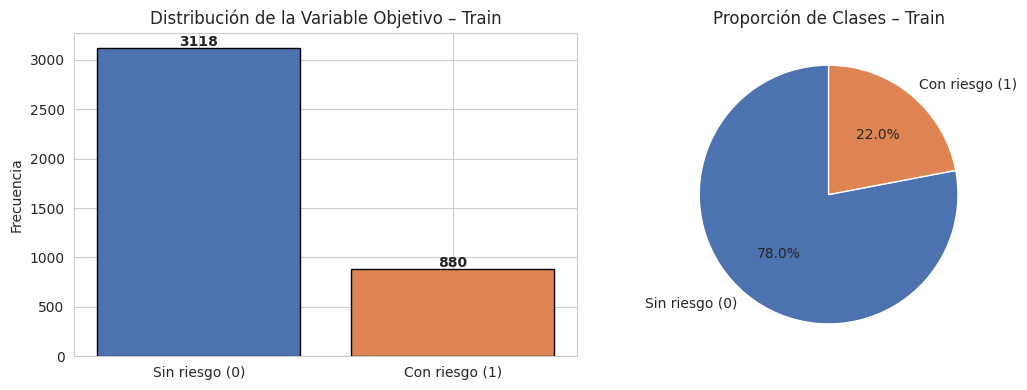

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

conteo_train = y_train.value_counts()
axes[0].bar(['Sin riesgo (0)', 'Con riesgo (1)'], conteo_train.values,
            color=['#4C72B0','#DD8452'], edgecolor='black')
for i, v in enumerate(conteo_train.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribución de la Variable Objetivo – Train')
axes[0].set_ylabel('Frecuencia')

axes[1].pie(conteo_train.values, labels=['Sin riesgo (0)','Con riesgo (1)'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Proporción de Clases – Train')

plt.tight_layout()
plt.show()


### 2.4 – Histogramas de variables numéricas por clase

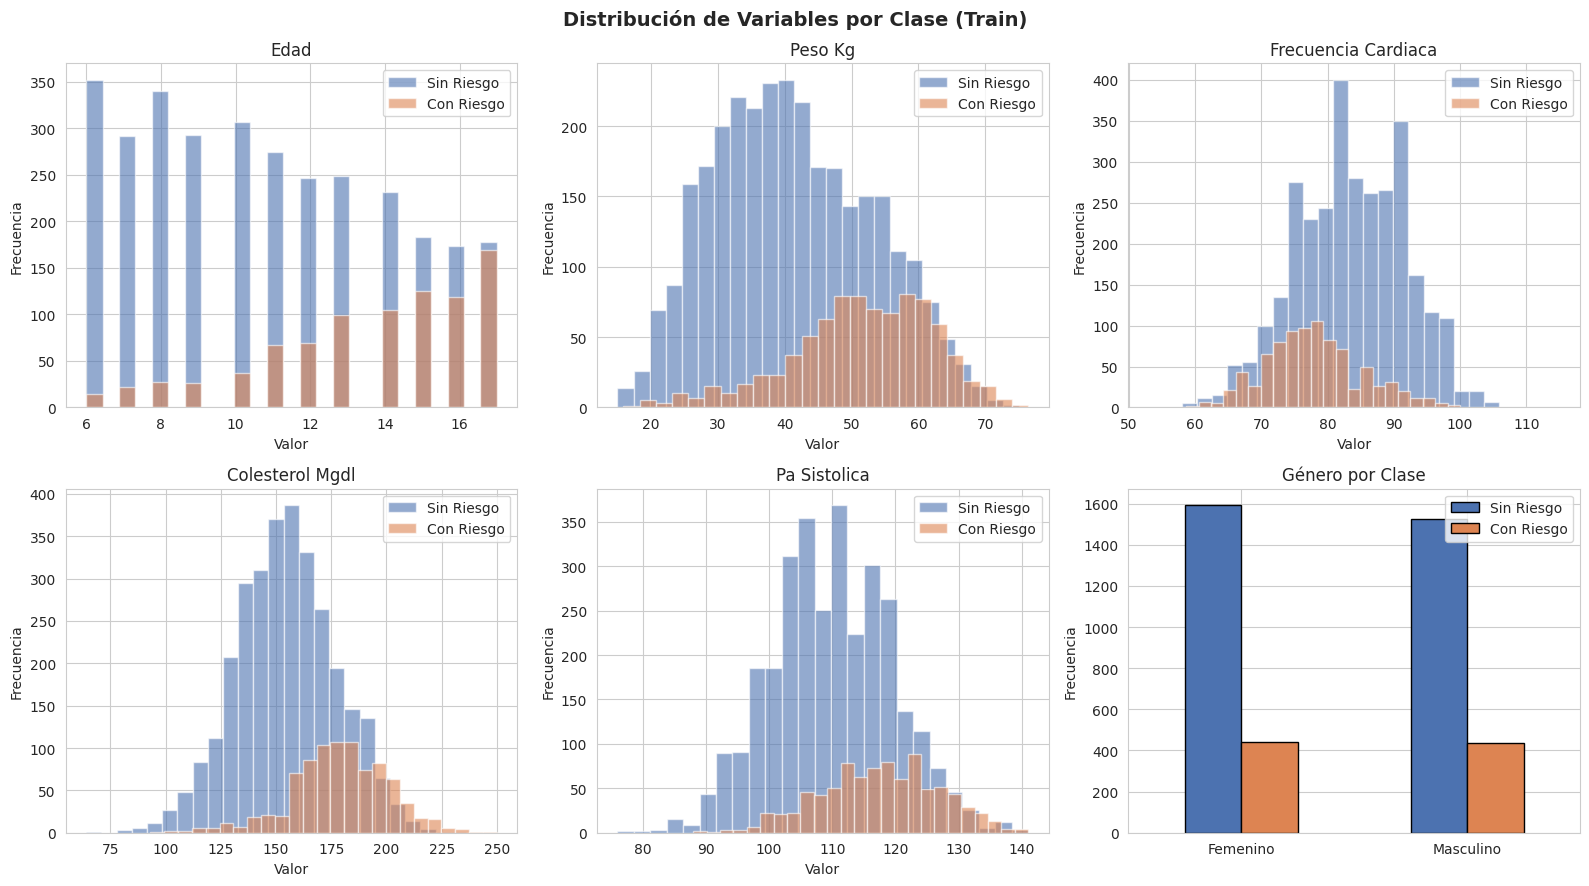

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for clase, color, lbl in [(0,'#4C72B0','Sin Riesgo'),(1,'#DD8452','Con Riesgo')]:
        datos = df_train_eda[df_train_eda['riesgo_cv']==clase][col].dropna()
        axes[i].hist(datos, bins=25, alpha=0.6, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Último eje: género
genero_clase = df_train_eda.groupby(['genero','riesgo_cv']).size().unstack(fill_value=0)
genero_clase.index = ['Femenino','Masculino']
genero_clase.columns = ['Sin Riesgo','Con Riesgo']
genero_clase.plot(kind='bar', ax=axes[5], color=['#4C72B0','#DD8452'],
                  edgecolor='black', rot=0)
axes[5].set_title('Género por Clase')
axes[5].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables por Clase (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.5 – Boxplots por clase

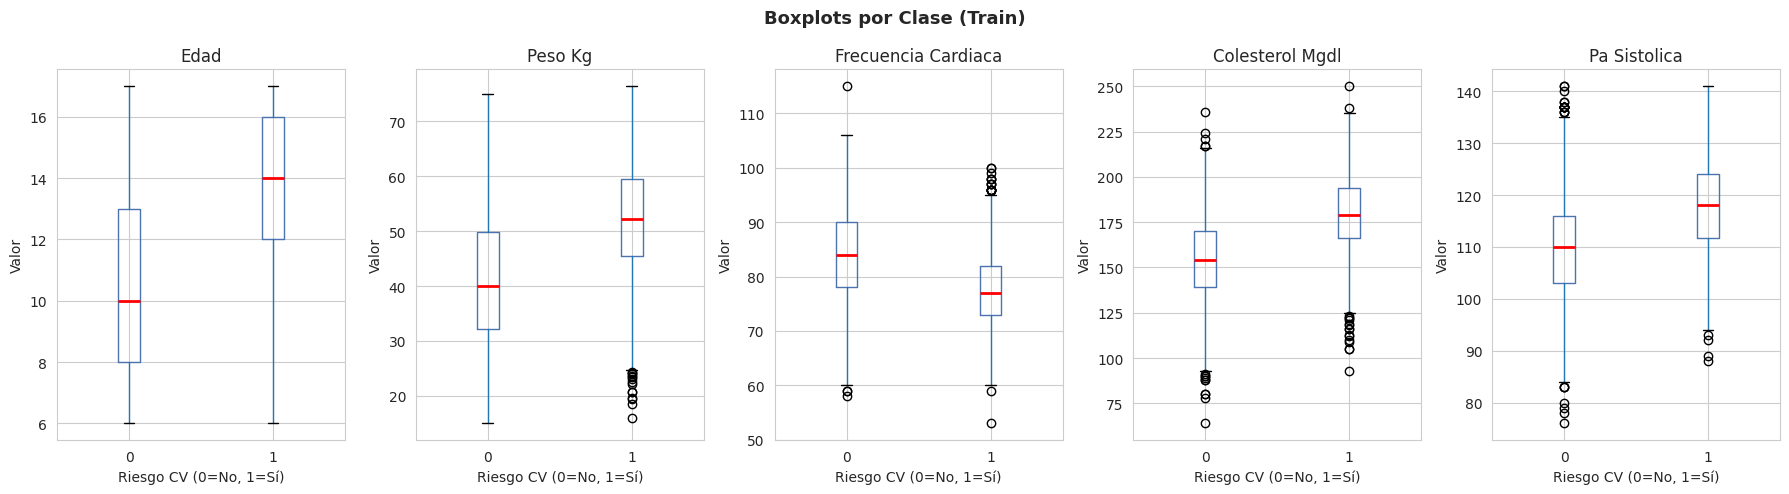

In [ ]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    df_train_eda.boxplot(column=col, by='riesgo_cv', ax=ax,
                         boxprops=dict(color='#4C72B0'),
                         medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_',' ').title())
    ax.set_xlabel('Riesgo CV (0=No, 1=Sí)')
    ax.set_ylabel('Valor')

plt.suptitle('Boxplots por Clase (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.6 – Promedio de variables por clase

In [ ]:
print('Promedio de variables numéricas según riesgo_cv:\n')
print(df_train_eda.groupby('riesgo_cv')[num_cols].mean().round(2).to_string())


Promedio de variables numéricas según riesgo_cv:

            edad  peso_kg  frecuencia_cardiaca  colesterol_mgdl  pa_sistolica
riesgo_cv                                                                    
0          10.76    41.13                83.50           154.49        109.71
1          13.68    51.57                77.89           178.97        117.55


### 2.7 – Matriz de correlación (train)

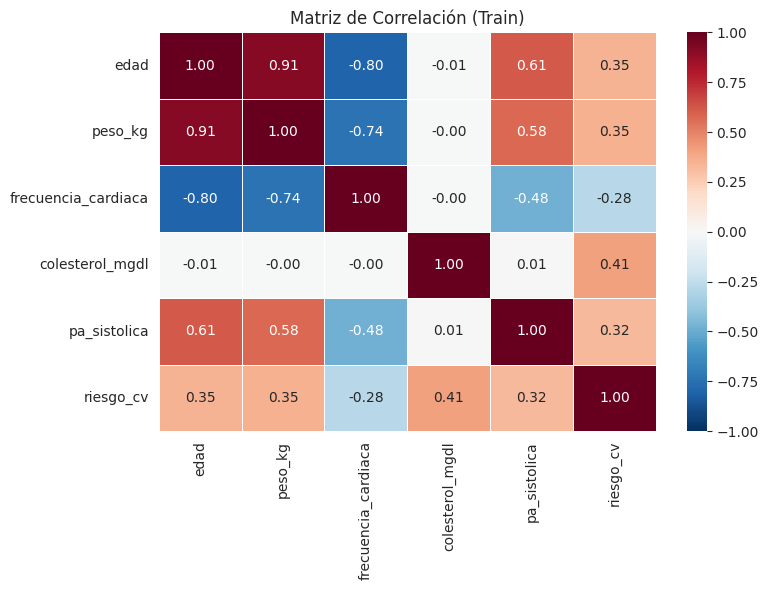

In [ ]:
corr = df_train_eda[num_cols + ['riesgo_cv']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación (Train)')
plt.tight_layout()
plt.show()


---
## 🔹 FASE 2B – EXPLORE AVANZADO: Clustering con K-Means y Reducción de Dimensionalidad con PCA

Esta sección complementa el análisis exploratorio con técnicas **no supervisadas** para:

- Descubrir agrupaciones naturales de pacientes sin usar la etiqueta `riesgo_cv`
- Reducir la dimensionalidad con **PCA** y visualizar la estructura latente de los datos
- Identificar qué variables explican la mayor varianza en la población pediátrica

> **Nota metodológica:** el clustering se aplica sobre el dataset limpio completo
> (`df_clean`) con un scaler independiente del pipeline supervisado.
> Al ser un análisis **descriptivo** (no predictivo), los clusters **no se usan como
> features en los modelos** y por tanto no constituyen data leakage.


### 2B.1 – Preparación de datos para Clustering

In [ ]:
FEATURES_CLU = ["edad","genero","peso_kg","pa_sistolica",
                "frecuencia_cardiaca","colesterol_mgdl"]

df_clu = df_clean[FEATURES_CLU + ['riesgo_cv']].copy()

# Imputar nulos con medianas del dataset completo (análisis descriptivo)
for col in FEATURES_CLU:
    if df_clu[col].isnull().any():
        df_clu[col] = df_clu[col].fillna(df_clu[col].median())

# Scaler propio (no contaminar el pipeline supervisado)
scaler_clu = StandardScaler()
X_clu = scaler_clu.fit_transform(df_clu[FEATURES_CLU])

print(f"Dimensiones para clustering: {X_clu.shape}")
print(f"Nulos restantes: {pd.isnull(X_clu).sum()}")
print("\nPrimeras 5 filas escaladas:\n")
print(pd.DataFrame(X_clu, columns=FEATURES_CLU).head().round(3).to_string())


Dimensiones para clustering: (4998, 6)
Nulos restantes: 0

Primeras 5 filas escaladas:

    edad  genero  peso_kg  pa_sistolica  frecuencia_cardiaca  colesterol_mgdl
0  0.161   1.011   -0.096        -0.251               -0.261            0.050
1 -0.703  -0.989   -0.765        -0.945               -0.261           -0.440
2  1.313  -0.989    1.540         0.442               -0.971            0.376
3  0.449   1.011    0.176        -1.936               -1.089            0.499
4 -0.415   1.011   -0.683         0.046                0.094           -0.766


### 2B.2 – Determinación del K óptimo: Método del Codo + Silhouette Score

Se usan dos criterios complementarios:

- **Inercia (método del codo):** mide la compactness interna; se busca el punto de inflexión donde añadir más clusters deja de aportar mejora significativa.
- **Silhouette Score:** mide qué tan bien separados están los clusters respecto a los vecinos (rango: −1 a 1; valores más altos = clusters más definidos).


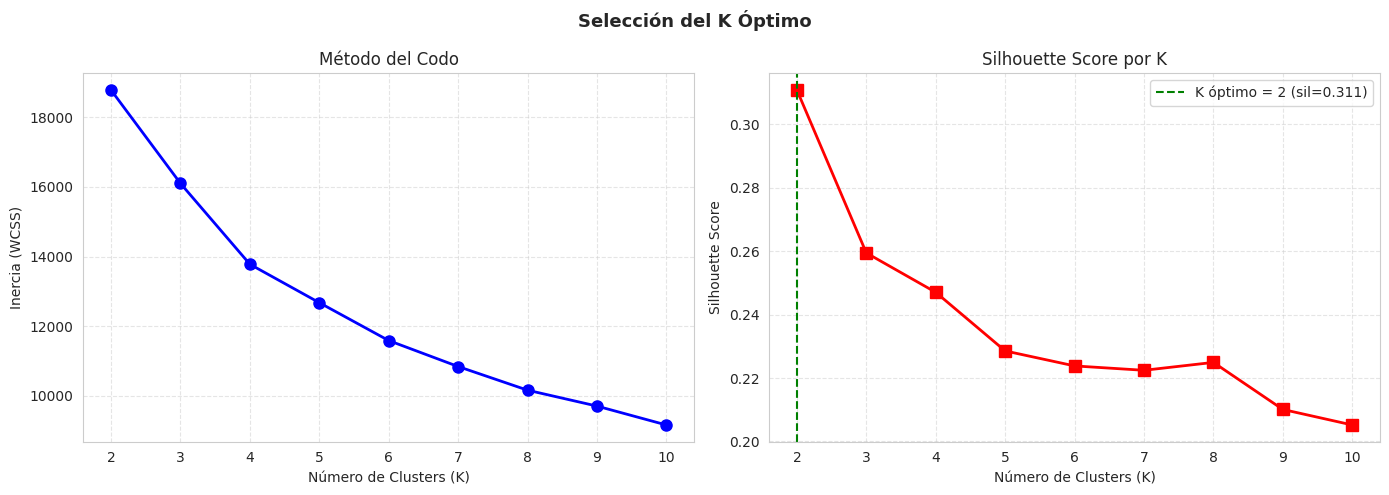


Silhouette Scores:
  K=2: 0.3108 ← mayor
  K=3: 0.2595
  K=4: 0.2470
  K=5: 0.2286
  K=6: 0.2238
  K=7: 0.2225
  K=8: 0.2249
  K=9: 0.2101
  K=10: 0.2052


In [ ]:
K_RANGE     = range(2, 11)
inercias    = []
silhouettes = []

for k in K_RANGE:
    km_tmp     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels_tmp = km_tmp.fit_predict(X_clu)
    inercias.append(km_tmp.inertia_)
    silhouettes.append(silhouette_score(X_clu, labels_tmp,
                                        sample_size=2000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].grid(True, linestyle='--', alpha=0.5)

k_mejor_sil = list(K_RANGE)[silhouettes.index(max(silhouettes))]
axes[1].plot(list(K_RANGE), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=k_mejor_sil, color='green', linestyle='--',
                label=f'K óptimo = {k_mejor_sil} (sil={max(silhouettes):.3f})')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Selección del K Óptimo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_RANGE, silhouettes):
    marca = ' ← mayor' if k == k_mejor_sil else ''
    print(f"  K={k}: {s:.4f}{marca}")


### 2B.3 – Aplicación de K-Means con K óptimo

Se entrena el modelo K-Means con el número de clusters indicado por las métricas.
El parámetro `N_CLUSTERS_OPTIMO` puede modificarse si el criterio clínico sugiere un valor diferente.


In [ ]:
N_CLUSTERS_OPTIMO = 4 # Método del codo

kmeans = KMeans(n_clusters=N_CLUSTERS_OPTIMO, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_clu)

df_clu['cluster'] = cluster_labels

sil_final = silhouette_score(X_clu, cluster_labels,
                              sample_size=2000, random_state=RANDOM_STATE)

print(f"✅ K-Means con K = {N_CLUSTERS_OPTIMO}")
print(f"   Silhouette Score : {sil_final:.4f}")
print(f"   Inercia          : {kmeans.inertia_:.2f}")
print(f"\nDistribución de pacientes por cluster:")
vc_clu = df_clu['cluster'].value_counts().sort_index()
for c, n in vc_clu.items():
    print(f"  Cluster {c}: {n} pacientes ({n/len(df_clu)*100:.1f}%)")


✅ K-Means con K = 4
   Silhouette Score : 0.2470
   Inercia          : 13778.71

Distribución de pacientes por cluster:
  Cluster 0: 1217 pacientes (24.3%)
  Cluster 1: 1254 pacientes (25.1%)
  Cluster 2: 1327 pacientes (26.6%)
  Cluster 3: 1200 pacientes (24.0%)


### 2B.4 – Análisis de la estructura de los clusters

Se examina el perfil clínico promedio de cada cluster y su relación con la variable objetivo `riesgo_cv`.


In [ ]:
# Perfil promedio por cluster
cluster_perfil = df_clu.groupby('cluster')[FEATURES_CLU].mean().round(2)
print("Características promedio por cluster:\n")
print(cluster_perfil.to_string())

# Tabla de contingencia cluster vs riesgo_cv
print("\nTabla de contingencia – Cluster vs Riesgo Cardiovascular:\n")
contingencia = pd.crosstab(df_clu['cluster'], df_clu['riesgo_cv'],
                            margins=True, margins_name='Total')
contingencia.columns.name = None
contingencia.columns = ['Sin Riesgo (0)', 'Con Riesgo (1)', 'Total']
contingencia['% Con Riesgo'] = (
    contingencia['Con Riesgo (1)'] / contingencia['Total'] * 100).round(1)

print(contingencia.to_string())


Características promedio por cluster:

          edad  genero  peso_kg  pa_sistolica  frecuencia_cardiaca  colesterol_mgdl
cluster                                                                            
0         8.53     1.0    34.21        105.28                88.43           159.99
1        14.36     1.0    53.13        117.77                75.92           160.06
2         8.62     0.0    34.26        105.72                88.29           158.56
3        14.46     0.0    53.34        117.80                75.72           160.61

Tabla de contingencia – Cluster vs Riesgo Cardiovascular:

         Sin Riesgo (0)  Con Riesgo (1)  Total  % Con Riesgo
cluster                                                     
0                  1111             106   1217           8.7
1                   812             442   1254          35.2
2                  1220             107   1327           8.1
3                   755             445   1200          37.1
Total              3898        

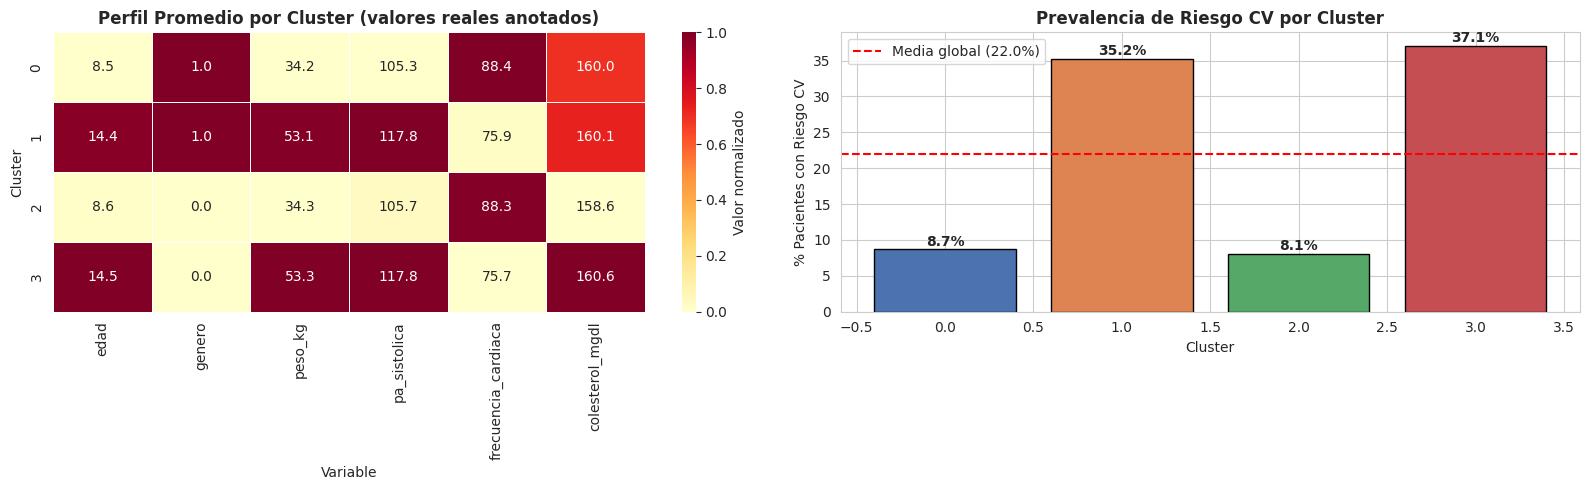

In [ ]:
# Heatmap de perfiles + prevalencia de riesgo por cluster
perfil_norm = (cluster_perfil - cluster_perfil.min()) / (cluster_perfil.max() - cluster_perfil.min())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(perfil_norm, annot=cluster_perfil, fmt='.1f',
            cmap='YlOrRd', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Valor normalizado'})
axes[0].set_title('Perfil Promedio por Cluster (valores reales anotados)', fontweight='bold')
axes[0].set_xlabel('Variable')
axes[0].set_ylabel('Cluster')

riesgo_cluster = df_clu.groupby('cluster')['riesgo_cv'].mean() * 100
colores_clu = ['#4C72B0','#DD8452','#55A868','#C44E52',
               '#8172B2','#937860'][:N_CLUSTERS_OPTIMO]
bars = axes[1].bar(riesgo_cluster.index, riesgo_cluster.values,
                   color=colores_clu, edgecolor='black')
media_global = df_clean['riesgo_cv'].mean() * 100
axes[1].axhline(y=media_global, color='red', linestyle='--',
                label=f'Media global ({media_global:.1f}%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% Pacientes con Riesgo CV')
axes[1].set_title('Prevalencia de Riesgo CV por Cluster', fontweight='bold')
axes[1].legend()
for bar, val in zip(bars, riesgo_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 2B.5 – Reducción de Dimensionalidad con PCA

El **Análisis de Componentes Principales (PCA)** transforma las 6 variables originales en
componentes ortogonales ordenados por la varianza que explican. Sirve para:

1. **Visualizar** la estructura de los clusters en 2D
2. **Cuantificar** cuánta información retiene cada componente
3. **Identificar** qué variables originales dominan cada dimensión (loadings)


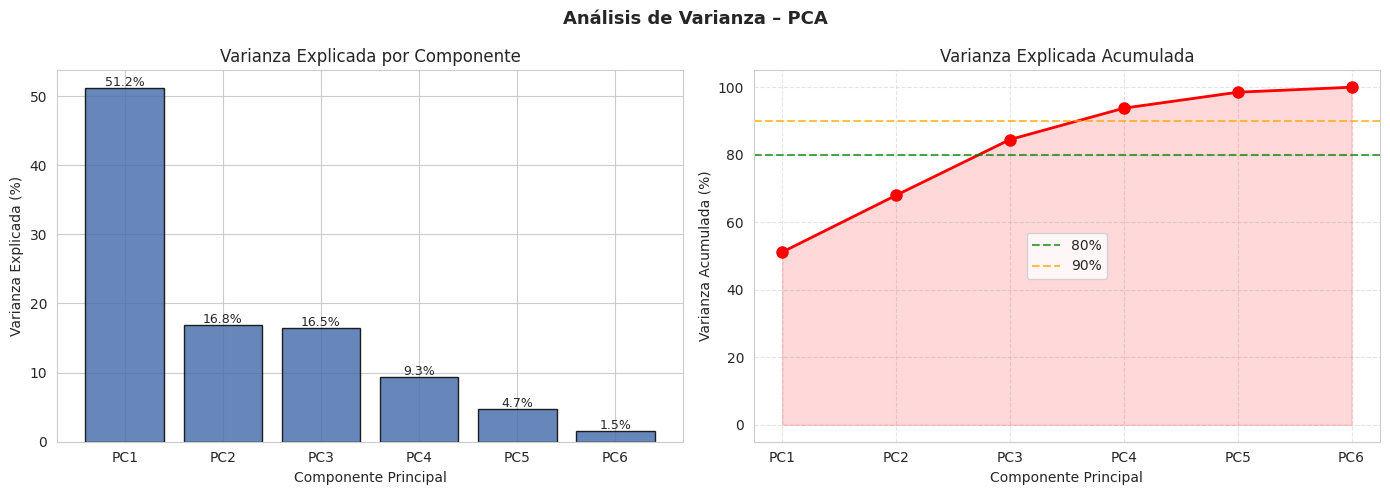

Varianza por componente:
  PC1: 51.17% (acumulada: 51.17%)
  PC2: 16.83% (acumulada: 68.00%)
  PC3: 16.50% (acumulada: 84.50%)
  PC4: 9.29% (acumulada: 93.80%)
  PC5: 4.72% (acumulada: 98.52%)
  PC6: 1.48% (acumulada: 100.00%)


In [ ]:
# PCA completo para analizar varianza explicada
pca_full = PCA(n_components=len(FEATURES_CLU), random_state=RANDOM_STATE)
pca_full.fit(X_clu)

var_exp  = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)
comps    = [f'PC{i+1}' for i in range(len(FEATURES_CLU))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comps, var_exp * 100, color='#4C72B0', edgecolor='black', alpha=0.85)
for i, v in enumerate(var_exp):
    axes[0].text(i, v*100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Varianza Explicada por Componente')

axes[1].plot(comps, var_acum * 100, 'ro-', linewidth=2, markersize=8)
axes[1].fill_between(range(len(comps)), var_acum * 100, alpha=0.15, color='red')
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[1].set_xticks(range(len(comps)))
axes[1].set_xticklabels(comps)
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Explicada Acumulada')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Análisis de Varianza – PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Varianza por componente:")
for i, (ve, va) in enumerate(zip(var_exp, var_acum)):
    print(f"  PC{i+1}: {ve*100:.2f}% (acumulada: {va*100:.2f}%)")


### 2B.6 – Loadings de PCA: contribución de las variables originales

Los **loadings** (pesos) indican la correlación entre cada variable original y cada
componente principal. Un valor absoluto alto significa que esa variable "empuja fuerte"
en esa dirección del espacio PCA.


Loadings de variables en los componentes principales:
                        PC1     PC2     PC3     PC4     PC5     PC6
edad                 0.5459 -0.0180  0.0057 -0.1631  0.2250  0.7902
genero               0.0139  0.6977  0.7162  0.0105 -0.0046  0.0046
peso_kg              0.5260 -0.0102  0.0100 -0.1818  0.6017 -0.5726
pa_sistolica         0.4238 -0.0017 -0.0202  0.8887 -0.1617 -0.0632
frecuencia_cardiaca -0.4954  0.0008  0.0067  0.3875  0.7488  0.2089
colesterol_mgdl      0.0092  0.7161 -0.6975 -0.0152  0.0176  0.0068


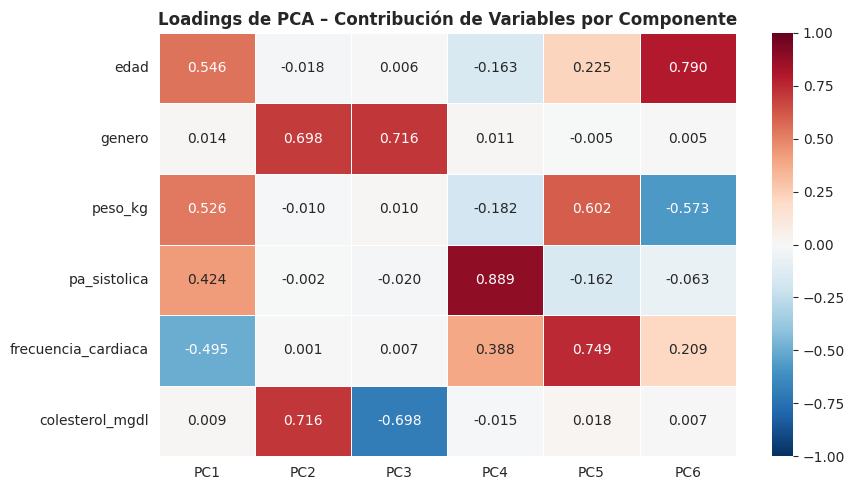

In [ ]:
pca_loadings = pd.DataFrame(
    pca_full.components_.T,
    index=FEATURES_CLU,
    columns=[f'PC{i+1}' for i in range(len(FEATURES_CLU))]
).round(4)

print("Loadings de variables en los componentes principales:")
print(pca_loadings.to_string())

# Heatmap de loadings
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pca_loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title('Loadings de PCA – Contribución de Variables por Componente', fontweight='bold')
plt.tight_layout()
plt.show()


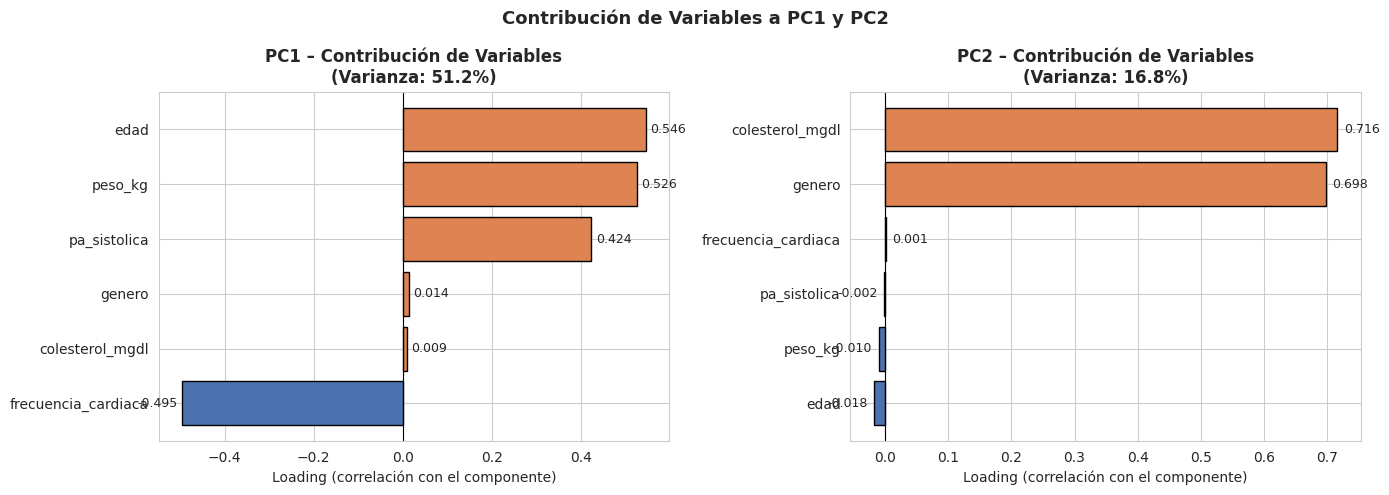

In [ ]:
# Gráficos de barras de contribución para PC1 y PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    loadings_pc = pca_loadings[pc].sort_values(ascending=True)
    colores_bar = ['#DD8452' if v >= 0 else '#4C72B0' for v in loadings_pc.values]
    ax.barh(loadings_pc.index, loadings_pc.values, color=colores_bar, edgecolor='black')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ve_pc = pca_full.explained_variance_ratio_[int(pc[-1])-1]
    ax.set_title(f'{pc} – Contribución de Variables\n(Varianza: {ve_pc*100:.1f}%)',
                 fontweight='bold')
    ax.set_xlabel('Loading (correlación con el componente)')
    for i, v in enumerate(loadings_pc.values):
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Contribución de Variables a PC1 y PC2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2B.7 – Visualización de clusters en espacio PCA 2D

Se proyectan los datos sobre los dos primeros componentes para visualizar los clusters.
Se muestran tres paneles:
1. **Por cluster** (etiqueta K-Means, con centroides marcados)
2. **Por riesgo CV real** (etiqueta supervisada, para validar coherencia clínica)
3. **Biplot** (vectores de las variables originales superpuestos sobre el espacio PCA)


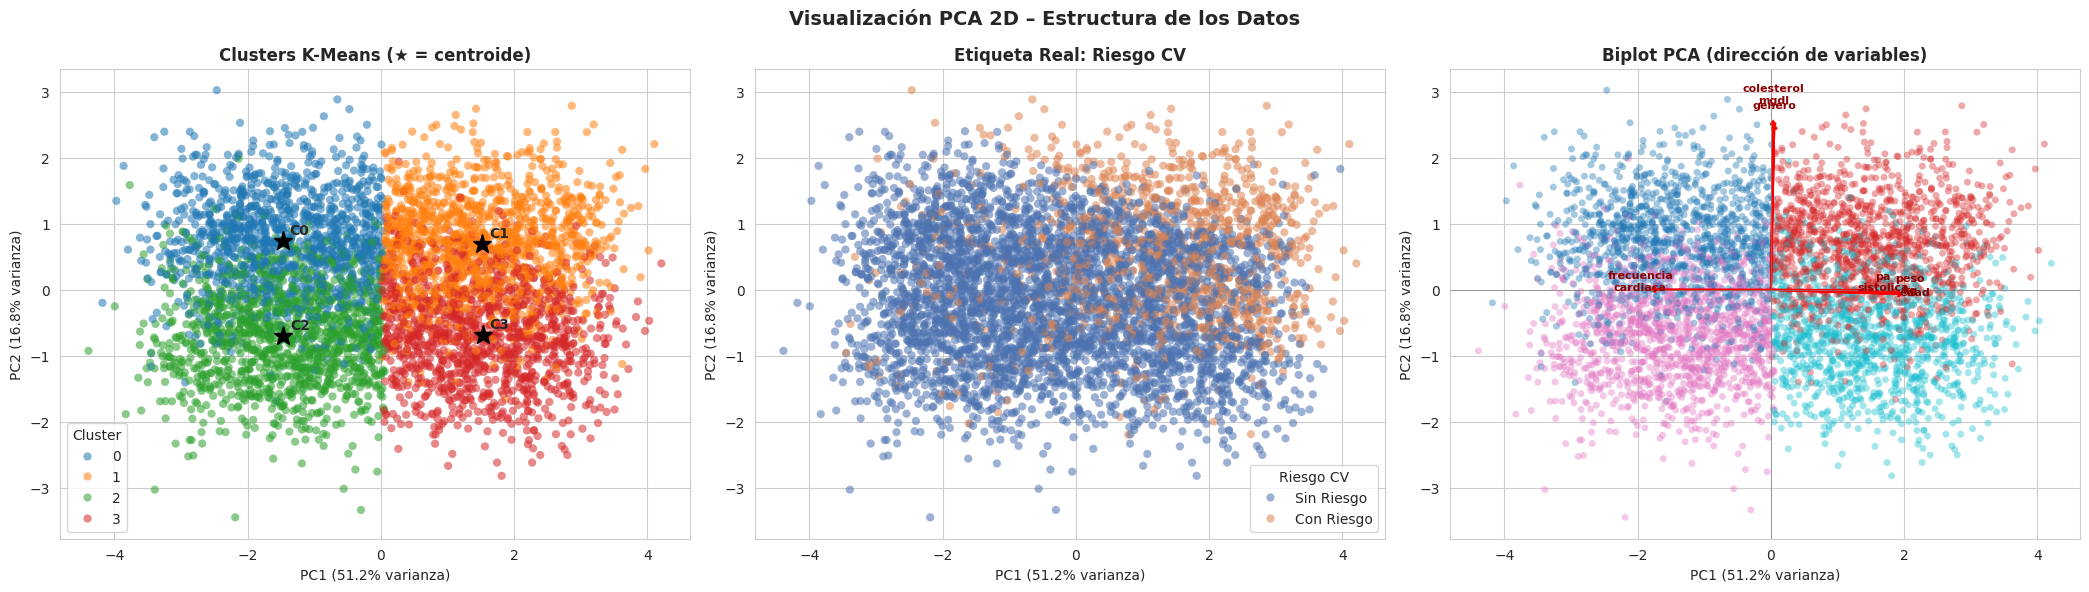

Varianza explicada por PC1 + PC2: 68.0%


In [ ]:
pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2  = pca_2d.fit_transform(X_clu)
var1, var2 = pca_2d.explained_variance_ratio_ * 100

df_pca = pd.DataFrame(X_pca2, columns=['PC1','PC2'])
df_pca['cluster']   = cluster_labels
df_pca['riesgo_cv'] = df_clean['riesgo_cv'].values

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: clusters con centroides
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster',
                palette='tab10', s=35, alpha=0.55, edgecolor='none', ax=axes[0])
centroides_2d = pca_2d.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroides_2d):
    axes[0].plot(cx, cy, 'k*', markersize=14)
    axes[0].annotate(f'C{i}', (cx, cy), xytext=(5,5),
                     textcoords='offset points', fontweight='bold', fontsize=10)
axes[0].set_xlabel(f'PC1 ({var1:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% varianza)')
axes[0].set_title('Clusters K-Means (★ = centroide)', fontweight='bold')
axes[0].legend(title='Cluster')

# Panel 2: riesgo CV real
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='riesgo_cv',
                palette={0:'#4C72B0', 1:'#DD8452'},
                s=35, alpha=0.55, edgecolor='none', ax=axes[1])
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Sin Riesgo','Con Riesgo'], title='Riesgo CV')
axes[1].set_xlabel(f'PC1 ({var1:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% varianza)')
axes[1].set_title('Etiqueta Real: Riesgo CV', fontweight='bold')

# Panel 3: biplot
axes[2].scatter(X_pca2[:,0], X_pca2[:,1],
                c=cluster_labels, cmap='tab10', s=25, alpha=0.4, edgecolor='none')
scale = 3.5
for j, feat in enumerate(FEATURES_CLU):
    vx = pca_2d.components_[0, j] * scale
    vy = pca_2d.components_[1, j] * scale
    axes[2].arrow(0, 0, vx, vy, head_width=0.08, head_length=0.05,
                  fc='red', ec='red', linewidth=1.5)
    axes[2].text(vx*1.13, vy*1.13, feat.replace('_','\n'),
                 ha='center', fontsize=8, color='darkred', fontweight='bold')
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].set_xlabel(f'PC1 ({var1:.1f}% varianza)')
axes[2].set_ylabel(f'PC2 ({var2:.1f}% varianza)')
axes[2].set_title('Biplot PCA (dirección de variables)', fontweight='bold')

plt.suptitle('Visualización PCA 2D – Estructura de los Datos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Varianza explicada por PC1 + PC2: {var1+var2:.1f}%")


### 2B.8 – Interpretación del PCA y los Clusters

#### Componente Principal 1 (PC1) – Maduración física y desarrollo somático
PC1 captura la dimensión de **desarrollo físico pediátrico**:
- Contribuciones altas y positivas de `edad`, `peso_kg` y `pa_sistolica`, que crecen con el desarrollo.
- Contribución negativa de `frecuencia_cardiaca`, que disminuye naturalmente con la edad en niños.

Un valor alto de PC1 corresponde a un **perfil de adolescente desarrollado**: mayor, más pesado, con más presión y menor frecuencia cardíaca.

#### Componente Principal 2 (PC2) – Factores de riesgo metabólico
PC2 captura una dimensión de **riesgo metabólico independiente del desarrollo físico**:
- `colesterol_mgdl` y `genero` son las variables dominantes.

Un valor alto de PC2 tiende a corresponder a pacientes masculinos con colesterol elevado, perfil clínicamente asociado a mayor riesgo cardiovascular.

#### Relación Clusters – Riesgo CV
Al superponer la etiqueta `riesgo_cv` sobre el espacio PCA se puede evaluar si los clusters
capturados de forma **no supervisada** son clínicamente relevantes:
- Los clusters con alta prevalencia de riesgo (ver tabla de contingencia) representan subgrupos prioritarios para el modelo supervisado.
- Esta información puede guisar el **diseño de features adicionales** o la **ponderación de errores de clasificación** por subgrupo en trabajos futuros.


---
## 🔹 FASE 3 – MODIFY

En esta fase se transforma el dataset de entrenamiento para que los modelos puedan aprender correctamente:

1. **Imputación** de valores nulos con medianas calculadas *solo en train* (sin data leakage)
2. **Escalado** estándar ajustado solo en train y aplicado a train y test
3. **Cálculo de pesos de clase** para compensar el desbalance 78/22


### 3.1 – Imputación con medianas de train (sin data leakage)

In [ ]:
COLS_IMPUTAR = ["peso_kg","colesterol_mgdl","pa_sistolica","genero"]

# Medianas calculadas SOLO en train
medianas_train = {c: X_train_raw[c].median()
                  for c in COLS_IMPUTAR if c in X_train_raw.columns}

print("Medianas de imputación (calculadas en train):")
for k, v in medianas_train.items():
    print(f"  {k}: {v}")

X_train_clean = X_train_raw.copy()
X_test_clean  = X_test_raw.copy()

for c in COLS_IMPUTAR:
    X_train_clean[c] = X_train_clean[c].fillna(medianas_train[c])
    X_test_clean[c]  = X_test_clean[c].fillna(medianas_train[c])  # misma mediana

print(f"\nNulos en train tras imputación: {X_train_clean.isnull().sum().sum()}")
print(f"Nulos en test  tras imputación: {X_test_clean.isnull().sum().sum()}")


Medianas de imputación (calculadas en train):
  peso_kg: 43.0
  colesterol_mgdl: 160.0
  pa_sistolica: 111.0
  genero: 0.0

Nulos en train tras imputación: 0
Nulos en test  tras imputación: 0


### 3.2 – Selección de features y escalado estándar

In [ ]:
FEATURES = ["edad","genero","peso_kg","pa_sistolica",
             "frecuencia_cardiaca","colesterol_mgdl"]

X_train = X_train_clean[FEATURES].copy()
X_test  = X_test_clean[FEATURES].copy()

# Scaler ajustado SOLO en train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Features: {FEATURES}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\nMedia en train escalado (debe ser ≈ 0): {X_train_scaled.mean(axis=0).round(3)}")
print(f"Std   en train escalado (debe ser ≈ 1): {X_train_scaled.std(axis=0).round(3)}")


Features: ['edad', 'genero', 'peso_kg', 'pa_sistolica', 'frecuencia_cardiaca', 'colesterol_mgdl']
X_train: (3998, 6)  |  X_test: (1000, 6)

Media en train escalado (debe ser ≈ 0): [ 0.  0. -0. -0. -0.  0.]
Std   en train escalado (debe ser ≈ 1): [1. 1. 1. 1. 1. 1.]


### 3.3 – Cálculo de pesos de clase

In [ ]:
clases = np.unique(y_train)
pesos  = compute_class_weight('balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))

# Sample weights para Gradient Boosting (no acepta class_weight nativo)
sample_weights = compute_sample_weight('balanced', y_train)

print("Pesos de clase (para manejar desbalance):")
for k, v in class_weight_dict.items():
    nombre = 'Sin Riesgo' if k == 0 else 'Con Riesgo'
    print(f"  Clase {k} ({nombre}): peso = {v:.4f}")


Pesos de clase (para manejar desbalance):
  Clase 0 (Sin Riesgo): peso = 0.6411
  Clase 1 (Con Riesgo): peso = 2.2716


---
## 🔹 FASE 4 – MODEL

Cada modelo tiene su propia celda con:
- 📌 Descripción del algoritmo y cuándo usarlo en este contexto
- 🎛️ Hiperparámetros documentados con su rango útil y efecto
- ✅ Validación cruzada estratificada (5-fold) para estimar el rendimiento real
- La flecha `# ← AJUSTAR` señala exactamente dónde modificar cada hiperparámetro


### 4.0 – Función auxiliar de evaluación y validación cruzada

In [ ]:
cv_strat  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
resultados  = {}   # métricas por modelo
modelos_fit = {}   # modelos entrenados

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te,
                   usa_scaler=False, sw=None):
    """
    Entrena el modelo, evalúa con CV estratificada y en test.
    Parámetros
    ----------
    usa_scaler : bool – usar X_train_scaled / X_test_scaled en lugar de X_train / X_test
    sw         : array-like – sample_weight para fit (solo Gradient Boosting)
    """
    Xtr = X_train_scaled if usa_scaler else X_tr
    Xte = X_test_scaled  if usa_scaler else X_te

    # Validación cruzada
    cv_roc = cross_val_score(modelo, Xtr, y_tr, cv=cv_strat,
                              scoring='roc_auc', n_jobs=-1)
    cv_rec = cross_val_score(modelo, Xtr, y_tr, cv=cv_strat,
                              scoring='recall',  n_jobs=-1)

    # Ajuste final
    if sw is not None:
        modelo.fit(Xtr, y_tr, sample_weight=sw)
    else:
        modelo.fit(Xtr, y_tr)

    y_pred = modelo.predict(Xte)
    y_prob = modelo.predict_proba(Xte)[:,1]

    # Métricas test
    cm     = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rep    = classification_report(y_te, y_pred, output_dict=True)
    roc    = roc_auc_score(y_te, y_prob)
    pr     = average_precision_score(y_te, y_prob)

    res = {
        'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob,
        'cv_roc_mean': cv_roc.mean(), 'cv_roc_std': cv_roc.std(),
        'cv_rec_mean': cv_rec.mean(), 'cv_rec_std': cv_rec.std(),
        'accuracy':    rep['accuracy'],
        'precision_1': rep['1']['precision'],
        'recall_1':    rep['1']['recall'],
        'f1_1':        rep['1']['f1-score'],
        'specificity': tn/(tn+fp),
        'roc_auc': roc, 'pr_auc': pr, 'cm': cm,
    }

    print(f"\n{'='*55}")
    print(f" MODELO: {nombre}")
    print(f"{'='*55}")
    print(f"  CV ROC-AUC : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
    print(f"  CV Recall  : {cv_rec.mean():.4f} ± {cv_rec.std():.4f}")
    print(f"  TEST Accuracy    : {res['accuracy']:.4f}")
    print(f"  TEST Precision_1 : {res['precision_1']:.4f}")
    print(f"  TEST Recall_1    : {res['recall_1']:.4f}")
    print(f"  TEST F1_1        : {res['f1_1']:.4f}")
    print(f"  TEST Specificity : {res['specificity']:.4f}")
    print(f"  TEST ROC-AUC     : {res['roc_auc']:.4f}")
    print(f"  TEST PR-AUC      : {res['pr_auc']:.4f}")
    print(f"\n  Confusion Matrix:\n{cm}")
    return res

print("✅ Función de evaluación lista.")


✅ Función de evaluación lista.


### 4.1 – Logistic Regression

**Características:** modelo lineal, altamente interpretable (los coeficientes = importancia directa de cada variable). Adecuado cuando la relación entre features y log-odds es aproximadamente lineal. Bajo costo computacional.

**Requiere escalado:** sí (usa `X_train_scaled` / `X_test_scaled`).


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🎛️ Hiperparámetros – Logistic Regression
# ──────────────────────────────────────────────────────────────────────────────
# C (float)        : Inverso de la regularización. Menor C = más regularización.
#                    Prueba: [0.01, 0.1, 1, 10, 100]
# penalty (str)    : 'l2' estándar. 'l1' produce coefs dispersos (selección de features).
#                    'elasticnet' requiere solver='saga'.
# solver (str)     : 'lbfgs' para datos pequeños/medianos. 'saga' para l1/elasticnet.
# max_iter (int)   : Aumentar si aparece ConvergenceWarning. Rango: [200, 500, 1000]
# class_weight     : 'balanced' ajusta automáticamente por desbalance 78/22.
# ══════════════════════════════════════════════════════════════════════════════

lr = LogisticRegression(
    C            = 1.0,           # ← AJUSTAR: [0.01, 0.1, 1, 10]
    penalty      = 'l2',          # ← AJUSTAR: 'l1', 'l2', 'elasticnet'
    solver       = 'lbfgs',       # ← AJUSTAR: 'lbfgs', 'saga', 'liblinear'
    max_iter     = 1000,          # ← AJUSTAR: aumentar si no converge
    class_weight = 'balanced',    # ← AJUSTAR: 'balanced' o class_weight_dict
    random_state = RANDOM_STATE
)

resultados['Logistic Regression'] = evaluar_modelo(
    'Logistic Regression', lr,
    X_train_scaled, y_train, X_test_scaled, y_test,
    usa_scaler=True
)
modelos_fit['Logistic Regression'] = lr



 MODELO: Logistic Regression
  CV ROC-AUC : 0.8771 ± 0.0063
  CV Recall  : 0.8125 ± 0.0161
  TEST Accuracy    : 0.7950
  TEST Precision_1 : 0.5214
  TEST Recall_1    : 0.8318
  TEST F1_1        : 0.6410
  TEST Specificity : 0.7846
  TEST ROC-AUC     : 0.8890
  TEST PR-AUC      : 0.7852

  Confusion Matrix:
[[612 168]
 [ 37 183]]


### 4.2 – Decision Tree

**Características:** modelo no lineal, totalmente interpretable (árbol visualizable). Propenso a sobreajuste sin regularización. No requiere escalado.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🎛️ Hiperparámetros – Decision Tree
# ──────────────────────────────────────────────────────────────────────────────
# max_depth (int)         : Profundidad máxima. None = sin límite (sobreajuste).
#                           Prueba: [3, 5, 7, 10, None]
# min_samples_split (int) : Mín. muestras para dividir nodo. Prueba: [2, 5, 10, 20]
# min_samples_leaf (int)  : Mín. muestras en hoja. Aumentar reduce sobreajuste.
#                           Prueba: [1, 5, 10, 20]
# criterion (str)         : 'gini' más rápido. 'entropy' puede rendir mejor con desbalance.
# class_weight            : 'balanced' importante dado el desbalance 78/22.
# ══════════════════════════════════════════════════════════════════════════════

dt = DecisionTreeClassifier(
    max_depth         = 7,          # ← AJUSTAR: [3, 5, 7, 10, None]
    min_samples_split = 10,         # ← AJUSTAR: [2, 5, 10, 20]
    min_samples_leaf  = 5,          # ← AJUSTAR: [1, 5, 10, 20]
    criterion         = 'gini',     # ← AJUSTAR: 'gini' o 'entropy'
    class_weight      = 'balanced', # ← AJUSTAR: 'balanced' o class_weight_dict
    random_state      = RANDOM_STATE
)

resultados['Decision Tree'] = evaluar_modelo(
    'Decision Tree', dt, X_train, y_train, X_test, y_test)
modelos_fit['Decision Tree'] = dt



 MODELO: Decision Tree
  CV ROC-AUC : 0.8618 ± 0.0127
  CV Recall  : 0.7898 ± 0.0276
  TEST Accuracy    : 0.8380
  TEST Precision_1 : 0.5986
  TEST Recall_1    : 0.8000
  TEST F1_1        : 0.6848
  TEST Specificity : 0.8487
  TEST ROC-AUC     : 0.8511
  TEST PR-AUC      : 0.7230

  Confusion Matrix:
[[662 118]
 [ 44 176]]


### 4.3 – K-Nearest Neighbors (KNN)

**Características:** basado en distancia, **requiere escalado**. Sensible a ruido y outliers. No soporta `class_weight` nativo; el desbalance se compensa parcialmente con `weights='distance'`.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🎛️ Hiperparámetros – K-Nearest Neighbors
# ──────────────────────────────────────────────────────────────────────────────
# n_neighbors (int) : Número de vecinos k.
#                     Regla práctica de partida: sqrt(n_train).
#                     k pequeño = modelo complejo (sobreajuste).
#                     k grande  = modelo suave (posible subajuste).
#                     Prueba: [3, 5, 7, 11, 15, 21]
# weights (str)     : 'uniform' = todos los vecinos pesan igual.
#                     'distance' = vecinos más cercanos pesan más (mejor con desbalance).
# metric (str)      : 'euclidean' para variables continuas.
#                     'manhattan' más robusto a outliers residuales.
# ══════════════════════════════════════════════════════════════════════════════

knn = KNeighborsClassifier(
    n_neighbors = 11,             # ← AJUSTAR: [3, 5, 7, 11, 15, 21]
    weights     = 'distance',     # ← AJUSTAR: 'uniform' o 'distance'
    metric      = 'euclidean',    # ← AJUSTAR: 'euclidean', 'manhattan'
    n_jobs      = -1
)

resultados['K-Nearest Neighbors'] = evaluar_modelo(
    'K-Nearest Neighbors', knn,
    X_train_scaled, y_train, X_test_scaled, y_test,
    usa_scaler=True
)
modelos_fit['K-Nearest Neighbors'] = knn



 MODELO: K-Nearest Neighbors
  CV ROC-AUC : 0.8721 ± 0.0127
  CV Recall  : 0.6011 ± 0.0291
  TEST Accuracy    : 0.8900
  TEST Precision_1 : 0.8313
  TEST Recall_1    : 0.6273
  TEST F1_1        : 0.7150
  TEST Specificity : 0.9641
  TEST ROC-AUC     : 0.8811
  TEST PR-AUC      : 0.7749

  Confusion Matrix:
[[752  28]
 [ 82 138]]


### 4.4 – Random Forest

**Características:** ensemble de árboles de decisión (bagging). Alta capacidad predictiva, robusto a outliers y sobreajuste. Permite extraer importancia de variables. No requiere escalado.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🎛️ Hiperparámetros – Random Forest
# ──────────────────────────────────────────────────────────────────────────────
# n_estimators (int)       : Número de árboles. Más = más estable pero más lento.
#                            Prueba: [50, 100, 200, 500]
# max_depth (int/None)     : Profundidad de cada árbol. None = sin límite.
#                            Prueba: [5, 10, 15, None]
# max_features (str/float) : Features por split. 'sqrt' clásico para clasificación.
#                            Prueba: 'sqrt', 'log2', 0.5
# min_samples_leaf (int)   : Regularización. Prueba: [1, 3, 5, 10]
# class_weight             : 'balanced_subsample' recalcula pesos en cada árbol.
# ══════════════════════════════════════════════════════════════════════════════

rf = RandomForestClassifier(
    n_estimators      = 200,                # ← AJUSTAR: [100, 200, 500]
    max_depth         = 15,                 # ← AJUSTAR: [5, 10, 15, None]
    max_features      = 'sqrt',             # ← AJUSTAR: 'sqrt', 'log2', 0.5
    min_samples_leaf  = 3,                  # ← AJUSTAR: [1, 3, 5, 10]
    min_samples_split = 5,                  # ← AJUSTAR: [2, 5, 10]
    class_weight      = 'balanced',         # ← AJUSTAR: 'balanced', 'balanced_subsample'
    n_jobs            = -1,
    random_state      = RANDOM_STATE
)

resultados['Random Forest'] = evaluar_modelo(
    'Random Forest', rf, X_train, y_train, X_test, y_test)
modelos_fit['Random Forest'] = rf



 MODELO: Random Forest
  CV ROC-AUC : 0.8791 ± 0.0090
  CV Recall  : 0.7284 ± 0.0188
  TEST Accuracy    : 0.8840
  TEST Precision_1 : 0.7261
  TEST Recall_1    : 0.7591
  TEST F1_1        : 0.7422
  TEST Specificity : 0.9192
  TEST ROC-AUC     : 0.8824
  TEST PR-AUC      : 0.7849

  Confusion Matrix:
[[717  63]
 [ 53 167]]


### 4.5 – Gradient Boosting

**Características:** ensemble secuencial; cada árbol corrige los errores del anterior. Alta precisión en datos tabulares. Más propenso a sobreajuste que RF; requiere regularización cuidadosa. No acepta `class_weight`: se compensa con `sample_weight` en el `fit`.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 🎛️ Hiperparámetros – Gradient Boosting
# ──────────────────────────────────────────────────────────────────────────────
# n_estimators (int)   : Iteraciones de boosting. Más = más capacidad pero más overfitting.
#                        Prueba: [50, 100, 200, 300]
# learning_rate (float): Tasa de aprendizaje. learning_rate ↓ → n_estimators ↑.
#                        Prueba: [0.01, 0.05, 0.1, 0.2]
# max_depth (int)      : Profundidad del árbol base. Suele ser pequeño.
#                        Prueba: [2, 3, 4, 5]
# subsample (float)    : Fracción de muestras por árbol. < 1 añade aleatoriedad.
#                        Prueba: [0.6, 0.8, 1.0]
# min_samples_leaf (int): Regularización a nivel de hoja. Prueba: [1, 5, 10]
# ══════════════════════════════════════════════════════════════════════════════

gb = GradientBoostingClassifier(
    n_estimators  = 200,      # ← AJUSTAR: [100, 200, 300]
    learning_rate = 0.05,     # ← AJUSTAR: [0.01, 0.05, 0.1, 0.2]
    max_depth     = 4,        # ← AJUSTAR: [2, 3, 4, 5]
    subsample     = 0.8,      # ← AJUSTAR: [0.6, 0.8, 1.0]
    min_samples_leaf = 5,     # ← AJUSTAR: [1, 5, 10]
    random_state  = RANDOM_STATE
)

# Gradient Boosting no acepta class_weight → se usa sample_weight en el fit
resultados['Gradient Boosting'] = evaluar_modelo(
    'Gradient Boosting', gb, X_train, y_train, X_test, y_test,
    sw=sample_weights
)
modelos_fit['Gradient Boosting'] = gb



 MODELO: Gradient Boosting
  CV ROC-AUC : 0.8792 ± 0.0157
  CV Recall  : 0.6648 ± 0.0157
  TEST Accuracy    : 0.8570
  TEST Precision_1 : 0.6351
  TEST Recall_1    : 0.8227
  TEST F1_1        : 0.7168
  TEST Specificity : 0.8667
  TEST ROC-AUC     : 0.8887
  TEST PR-AUC      : 0.7769

  Confusion Matrix:
[[676 104]
 [ 39 181]]


---
## 🔹 FASE 5 – ASSESS

Evaluación comparativa completa de los modelos:
1. Tabla de métricas (test + validación cruzada)
2. Gráfico comparativo de métricas clave
3. Matrices de confusión
4. Curvas ROC
5. Curvas Precision-Recall
6. Validación cruzada con intervalos de confianza
7. Importancia de variables
8. Selección y exportación del modelo final


### 5.1 – Tabla comparativa de métricas

In [ ]:
metricas_df = pd.DataFrame([
    {
        'Modelo':      nombre,
        'CV_ROC_mean': round(r['cv_roc_mean'], 4),
        'CV_ROC_std':  round(r['cv_roc_std'],  4),
        'Accuracy':    round(r['accuracy'],     4),
        'Precision_1': round(r['precision_1'],  4),
        'Recall_1':    round(r['recall_1'],     4),
        'F1_1':        round(r['f1_1'],         4),
        'Specificity': round(r['specificity'],  4),
        'ROC_AUC':     round(r['roc_auc'],      4),
        'PR_AUC':      round(r['pr_auc'],       4),
    }
    for nombre, r in resultados.items()
]).set_index('Modelo')

print('='*70)
print('TABLA COMPARATIVA DE MÉTRICAS')
print('='*70)
print(metricas_df.to_string())

mejor_recall = metricas_df['Recall_1'].idxmax()
mejor_roc    = metricas_df['ROC_AUC'].idxmax()
print(f"\n🏆 Mayor Recall_1  (prioridad clínica) : {mejor_recall}")
print(f"🏆 Mayor ROC-AUC   (rendimiento global) : {mejor_roc}")


TABLA COMPARATIVA DE MÉTRICAS
                     CV_ROC_mean  CV_ROC_std  Accuracy  Precision_1  Recall_1    F1_1  Specificity  ROC_AUC  PR_AUC
Modelo                                                                                                             
Logistic Regression       0.8771      0.0063     0.795       0.5214    0.8318  0.6410       0.7846   0.8890  0.7852
Decision Tree             0.8618      0.0127     0.838       0.5986    0.8000  0.6848       0.8487   0.8511  0.7230
K-Nearest Neighbors       0.8721      0.0127     0.890       0.8313    0.6273  0.7150       0.9641   0.8811  0.7749
Random Forest             0.8791      0.0090     0.884       0.7261    0.7591  0.7422       0.9192   0.8824  0.7849
Gradient Boosting         0.8792      0.0157     0.857       0.6351    0.8227  0.7168       0.8667   0.8887  0.7769

🏆 Mayor Recall_1  (prioridad clínica) : Logistic Regression
🏆 Mayor ROC-AUC   (rendimiento global) : Logistic Regression


### 5.2 – Comparación visual de métricas clave

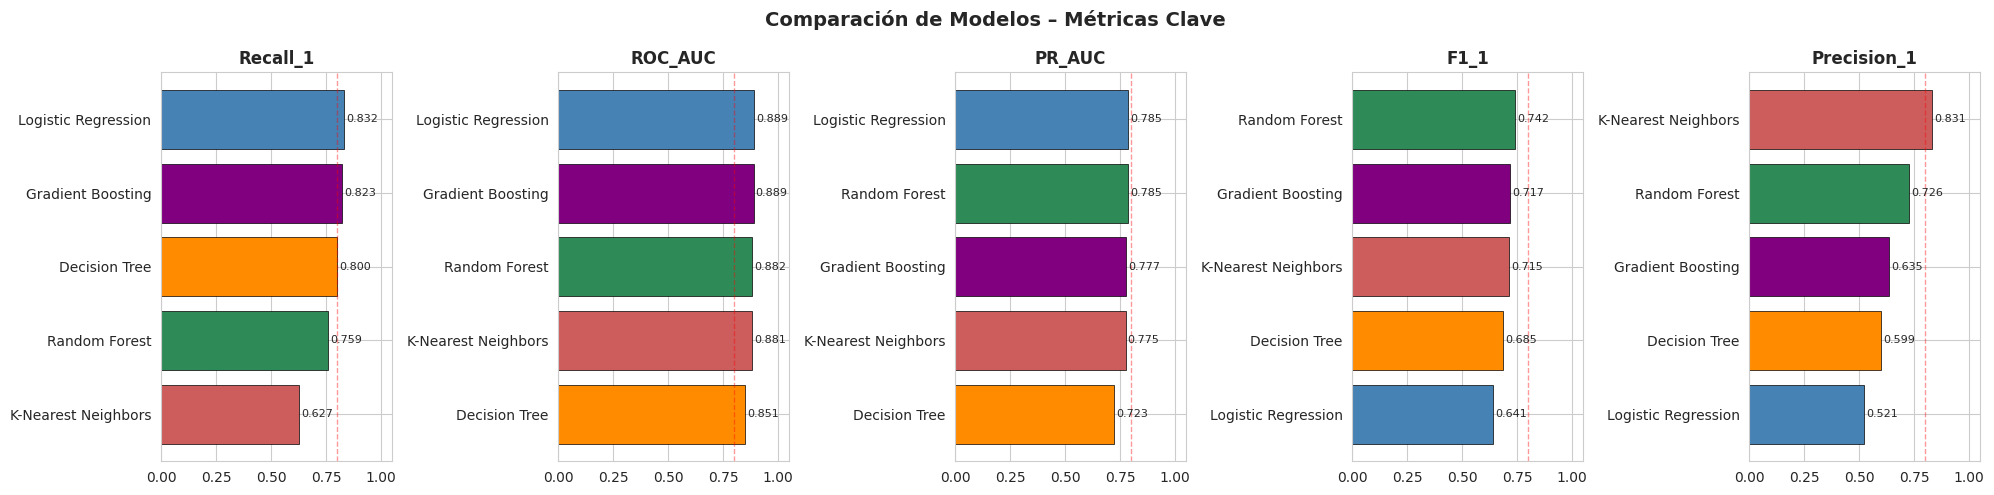

In [ ]:
metricas_plot = ['Recall_1', 'ROC_AUC', 'PR_AUC', 'F1_1', 'Precision_1']

fig, axes = plt.subplots(1, len(metricas_plot), figsize=(20, 5))
for ax, metrica in zip(axes, metricas_plot):
    valores = metricas_df[metrica].sort_values(ascending=True)
    colors  = [COLORES_MODELO[m] for m in valores.index]
    ax.barh(valores.index, valores.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_title(metrica, fontweight='bold')
    for i, v in enumerate(valores.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
    ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Comparación de Modelos – Métricas Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.3 – Matrices de confusión

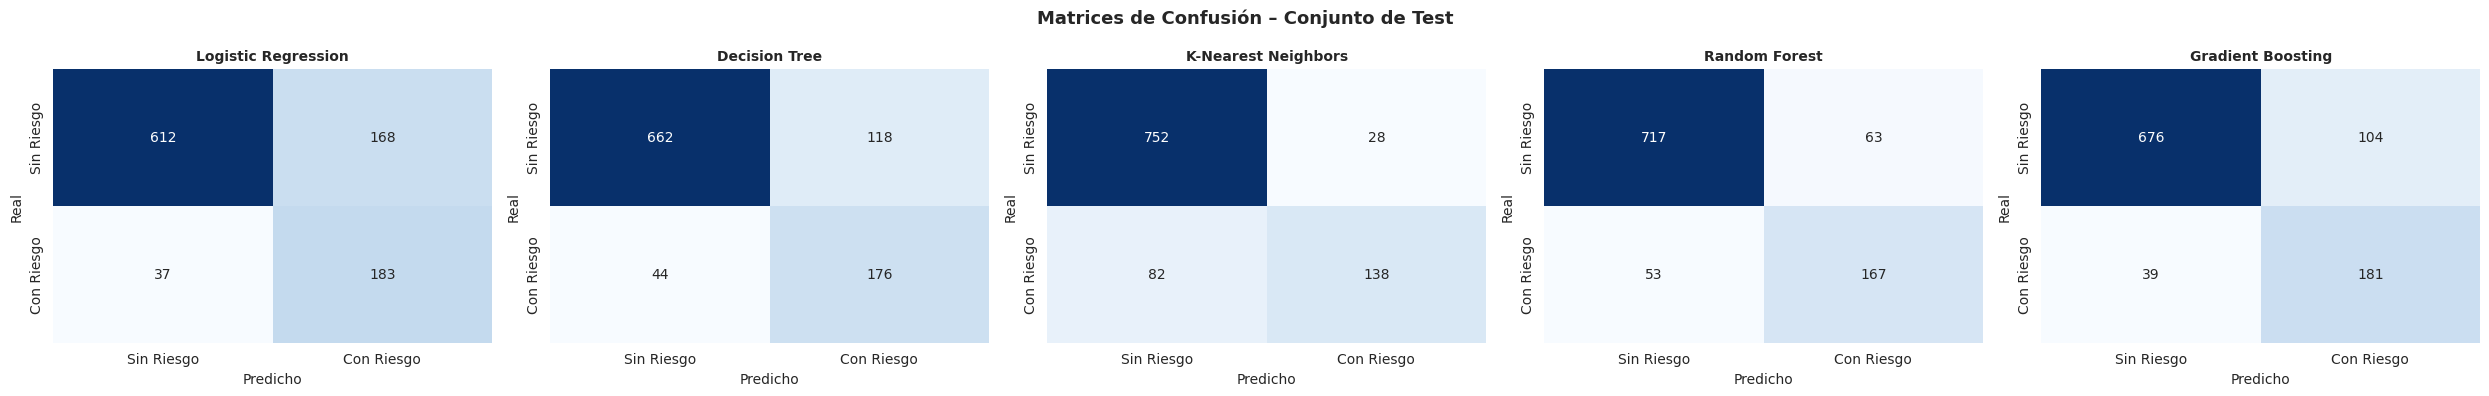

In [ ]:
fig, axes = plt.subplots(1, len(resultados), figsize=(5*len(resultados), 4))
for ax, (nombre, res) in zip(axes, resultados.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin Riesgo','Con Riesgo'],
                yticklabels=['Sin Riesgo','Con Riesgo'], cbar=False)
    ax.set_title(nombre, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión – Conjunto de Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 – Curvas ROC

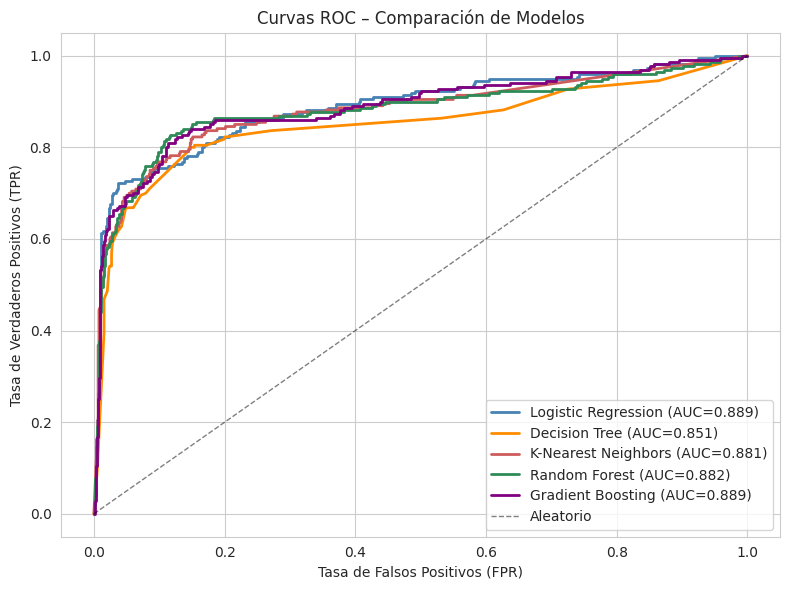

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={res['roc_auc']:.3f})",
            color=COLORES_MODELO[nombre], linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC – Comparación de Modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 5.5 – Curvas Precision-Recall

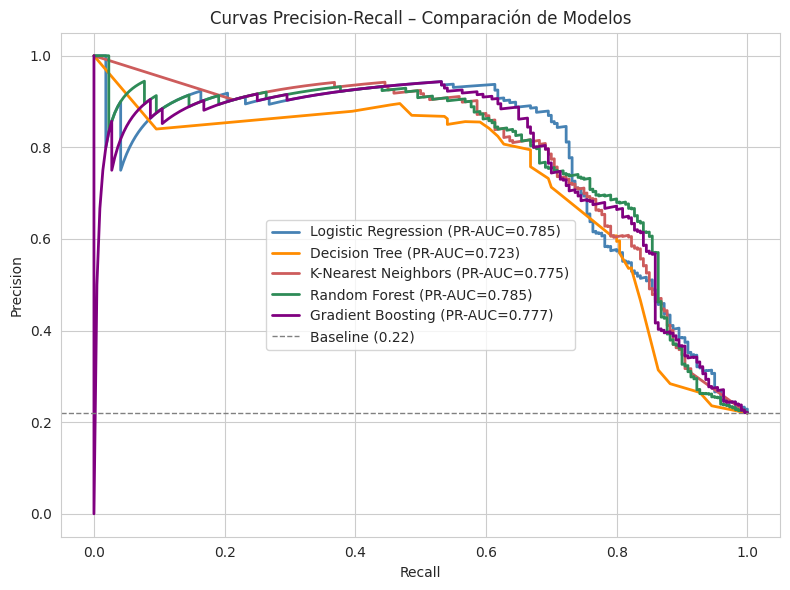

In [ ]:
baseline = y_test.mean()
fig, ax  = plt.subplots(figsize=(8, 6))
for nombre, res in resultados.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, label=f"{nombre} (PR-AUC={res['pr_auc']:.3f})",
            color=COLORES_MODELO[nombre], linewidth=2)
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall – Comparación de Modelos')
ax.legend()
plt.tight_layout()
plt.show()


### 5.6 – Validación cruzada con intervalos de confianza (IC 95%)

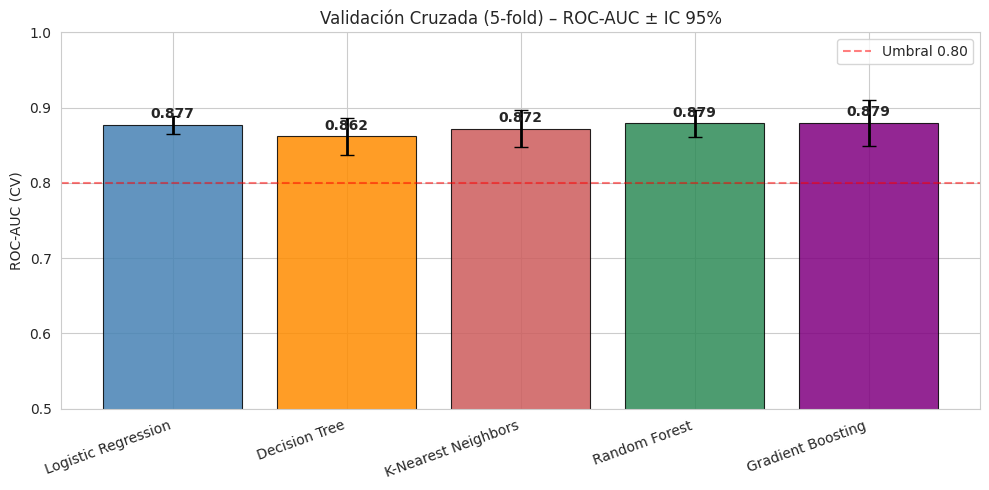

In [ ]:
nombres   = list(resultados.keys())
cv_means  = [resultados[m]['cv_roc_mean'] for m in nombres]
cv_stds   = [resultados[m]['cv_roc_std']  for m in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(nombres))
bars = ax.bar(x, cv_means,
              color=[COLORES_MODELO[m] for m in nombres],
              edgecolor='black', linewidth=0.8, alpha=0.85)
ax.errorbar(x, cv_means, yerr=[1.96*s for s in cv_stds],
            fmt='none', color='black', capsize=5, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=20, ha='right')
ax.set_ylabel('ROC-AUC (CV)')
ax.set_title(f'Validación Cruzada ({CV_FOLDS}-fold) – ROC-AUC ± IC 95%')
ax.set_ylim(0.5, 1.0)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Umbral 0.80')
ax.legend()
for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2., mean + 0.005,
            f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


### 5.7 – Importancia de Variables por Modelo

Se analiza qué variables influyen más en cada modelo. El método varía según el algoritmo:

- **Logistic Regression:** magnitud absoluta de los coeficientes — mayor valor = mayor influencia en la predicción.
- **Decision Tree:** reducción de impureza Gini acumulada por variable durante el entrenamiento. Interpretar con cautela: al ser un árbol único, es menos estable que un ensemble.
- **Random Forest y Gradient Boosting:** promedio de reducción de impureza Gini sobre todos los árboles — más robusto y confiable que el árbol individual.
- **KNN:** no tiene importancia nativa. Se usa *Permutation Importance*: mide cuánto cae el ROC-AUC al aleatorizar cada variable en el conjunto de test. Una caída grande indica que esa variable es crítica para el modelo.

> En todos los modelos, **Colesterol**, **Peso** y **PA Sistólica** tienden a ser los predictores más relevantes, lo cual es coherente con la literatura clínica de riesgo cardiovascular pediátrico.



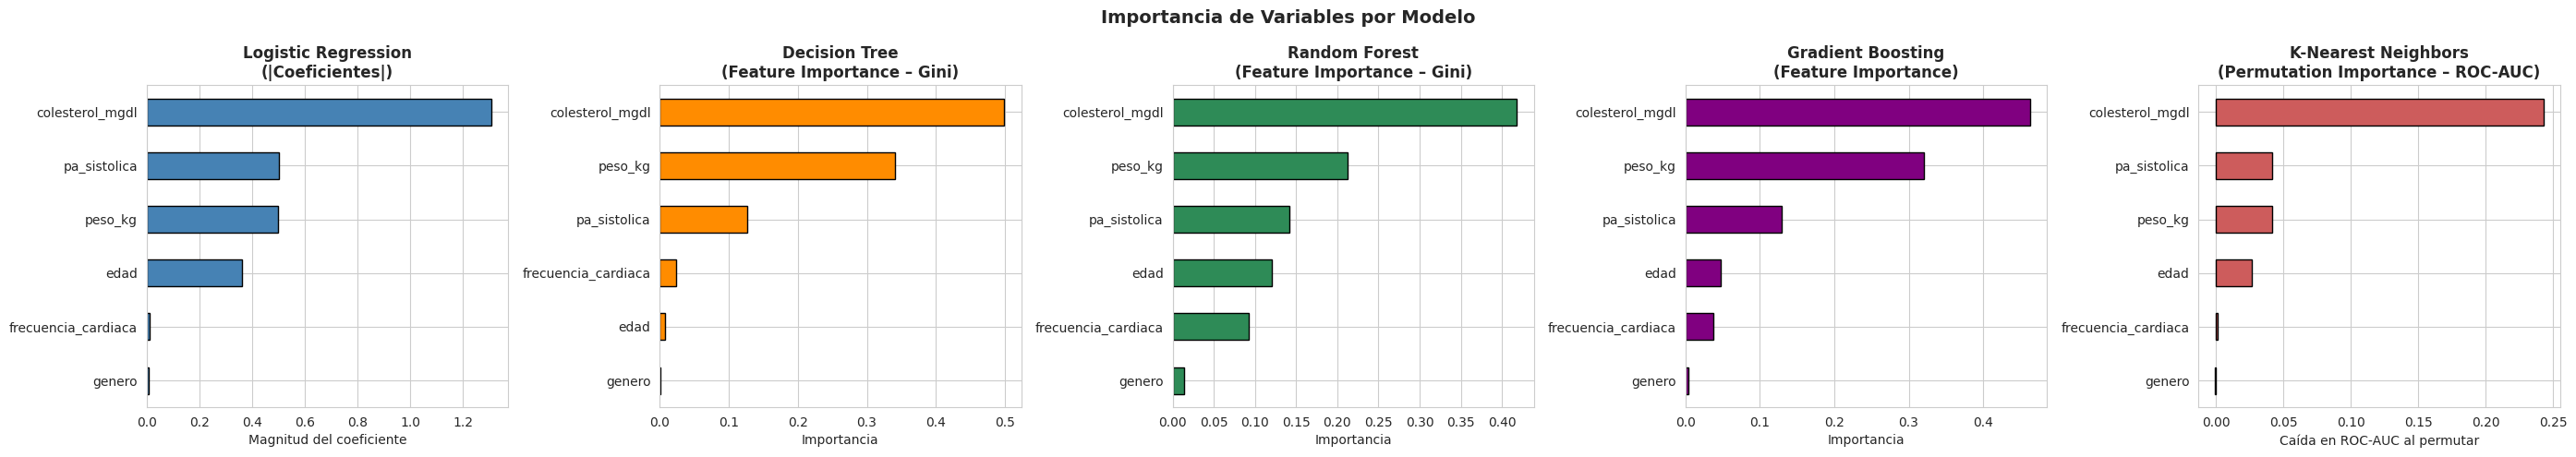

In [ ]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

# ── Logistic Regression – |coeficientes| ─────────────────────────────────────
coefs_lr = np.abs(resultados['Logistic Regression']['modelo'].coef_[0])
imp_lr   = pd.Series(coefs_lr, index=FEATURES).sort_values(ascending=True)
imp_lr.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Logistic Regression\n(|Coeficientes|)', fontweight='bold')
axes[0].set_xlabel('Magnitud del coeficiente')

# ── Decision Tree – feature_importances_ ─────────────────────────────────────
# Nota: menos estable que RF al ser un árbol único; interpretar con cautela
imp_dt = pd.Series(resultados['Decision Tree']['modelo'].feature_importances_,
                   index=FEATURES).sort_values(ascending=True)
imp_dt.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Decision Tree\n(Feature Importance – Gini)', fontweight='bold')
axes[1].set_xlabel('Importancia')

# ── Random Forest – feature_importances_ ─────────────────────────────────────
imp_rf = pd.Series(resultados['Random Forest']['modelo'].feature_importances_,
                   index=FEATURES).sort_values(ascending=True)
imp_rf.plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Random Forest\n(Feature Importance – Gini)', fontweight='bold')
axes[2].set_xlabel('Importancia')

# ── Gradient Boosting – feature_importances_ ─────────────────────────────────
imp_gb = pd.Series(resultados['Gradient Boosting']['modelo'].feature_importances_,
                   index=FEATURES).sort_values(ascending=True)
imp_gb.plot(kind='barh', ax=axes[3], color='purple', edgecolor='black')
axes[3].set_title('Gradient Boosting\n(Feature Importance)', fontweight='bold')
axes[3].set_xlabel('Importancia')

# ── KNN – Permutation Importance ─────────────────────────────────────────────
# KNN no tiene importancia nativa → se mide cuánto cae el ROC-AUC al
# permutar aleatoriamente cada variable (más lento pero agnóstico al modelo)
perm = permutation_importance(
    resultados['K-Nearest Neighbors']['modelo'],
    X_test_scaled, y_test,
    scoring='roc_auc',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
imp_knn = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)
imp_knn.plot(kind='barh', ax=axes[4], color='indianred', edgecolor='black')
axes[4].set_title('K-Nearest Neighbors\n(Permutation Importance – ROC-AUC)', fontweight='bold')
axes[4].set_xlabel('Caída en ROC-AUC al permutar')

plt.suptitle('Importancia de Variables por Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.8 – Selección y justificación del mejor modelo

**Criterio de selección:** se prioriza el **Recall_1** como métrica principal, ya que en
cribado pediátrico un falso negativo (niño con riesgo no detectado) tiene mayor costo
clínico que un falso positivo. El desempate se realiza por ROC-AUC y PR-AUC.


In [ ]:
# Mejor por Recall_1 (prioridad clínica)
mejor_modelo_nombre = metricas_df['Recall_1'].idxmax()
res_mejor = resultados[mejor_modelo_nombre]

print('═'*60)
print('COMPARACIÓN FINAL DE MODELOS')
print('═'*60)
print(metricas_df[['Recall_1','ROC_AUC','PR_AUC','F1_1','Accuracy']].to_string())

print(f"""
SELECCIÓN DEL MODELO FINAL
══════════════════════════
Modelo seleccionado : {mejor_modelo_nombre}
  Recall_1  : {res_mejor['recall_1']:.4f}  (↑ minimiza falsos negativos)
  ROC-AUC   : {res_mejor['roc_auc']:.4f}
  PR-AUC    : {res_mejor['pr_auc']:.4f}
  F1_1      : {res_mejor['f1_1']:.4f}

Justificación:
  En cribado pediátrico de riesgo CV, la prioridad es detectar
  todos los pacientes con riesgo real (maximizar Recall_1),
  aceptando una tasa moderada de falsos positivos que serán
  confirmados en una segunda evaluación clínica.
  La Regresión Logística, además, es el modelo más interpretable
  (coeficientes = peso de cada variable), facilitando la
  validación médica del modelo.
""")


════════════════════════════════════════════════════════════
COMPARACIÓN FINAL DE MODELOS
════════════════════════════════════════════════════════════
                     Recall_1  ROC_AUC  PR_AUC    F1_1  Accuracy
Modelo                                                          
Logistic Regression    0.8318   0.8890  0.7852  0.6410     0.795
Decision Tree          0.8000   0.8511  0.7230  0.6848     0.838
K-Nearest Neighbors    0.6273   0.8811  0.7749  0.7150     0.890
Random Forest          0.7591   0.8824  0.7849  0.7422     0.884
Gradient Boosting      0.8227   0.8887  0.7769  0.7168     0.857

SELECCIÓN DEL MODELO FINAL
══════════════════════════
Modelo seleccionado : Logistic Regression
  Recall_1  : 0.8318  (↑ minimiza falsos negativos)
  ROC-AUC   : 0.8890
  PR-AUC    : 0.7852
  F1_1      : 0.6410

Justificación:
  En cribado pediátrico de riesgo CV, la prioridad es detectar
  todos los pacientes con riesgo real (maximizar Recall_1),
  aceptando una tasa moderada de falsos pos

### 5.9 – Exportación del modelo, scaler y medianas

In [ ]:
# NOTA: Exportar scaler y medianas junto al modelo
# Sin esto, el modelo no puede usarse correctamente en producción
modelo_final = modelos_fit[mejor_modelo_nombre]

joblib.dump(modelo_final,    'modelo_riesgo_cv.pkl')
joblib.dump(scaler,          'scaler_riesgo_cv.pkl')
joblib.dump(medianas_train,  'medianas_imputacion.pkl')

print('✅ Archivos exportados:')
print('   modelo_riesgo_cv.pkl     – modelo entrenado')
print('   scaler_riesgo_cv.pkl     – scaler (requerido para LR y KNN)')
print('   medianas_imputacion.pkl  – medianas de imputación')


✅ Archivos exportados:
   modelo_riesgo_cv.pkl     – modelo entrenado
   scaler_riesgo_cv.pkl     – scaler (requerido para LR y KNN)
   medianas_imputacion.pkl  – medianas de imputación


### 5.10 – Ejemplo de predicción en producción

In [ ]:
def predecir_riesgo_cv(paciente_dict):
    """
    Predice riesgo CV para un paciente nuevo.
    Parámetros
    ----------
    paciente_dict : dict con claves:
        edad, genero (0=fem/1=masc), peso_kg, pa_sistolica,
        frecuencia_cardiaca, colesterol_mgdl
    Retorna
    -------
    dict con 'prediccion' (0/1) y 'probabilidad_riesgo'
    """
    _modelo   = joblib.load('modelo_riesgo_cv.pkl')
    _scaler   = joblib.load('scaler_riesgo_cv.pkl')
    _medianas = joblib.load('medianas_imputacion.pkl')

    df_p = pd.DataFrame([paciente_dict])
    for col, med in _medianas.items():
        if col in df_p.columns:
            df_p[col] = df_p[col].fillna(med)

    X_p  = _scaler.transform(df_p[FEATURES])
    pred = _modelo.predict(X_p)[0]
    prob = _modelo.predict_proba(X_p)[0][1]
    return {'prediccion': int(pred), 'probabilidad_riesgo': round(prob, 4)}


# Ejemplo
paciente = {
    'edad': 12, 'genero': 1, 'peso_kg': 55.0,
    'pa_sistolica': 120.0, 'frecuencia_cardiaca': 85.0,
    'colesterol_mgdl': 200.0
}
resultado = predecir_riesgo_cv(paciente)
print(f"Paciente: {paciente}")
print(f"Predicción: {'CON RIESGO' if resultado['prediccion'] == 1 else 'SIN RIESGO'}")
print(f"Probabilidad de riesgo: {resultado['probabilidad_riesgo']:.1%}")


Paciente: {'edad': 12, 'genero': 1, 'peso_kg': 55.0, 'pa_sistolica': 120.0, 'frecuencia_cardiaca': 85.0, 'colesterol_mgdl': 200.0}
Predicción: CON RIESGO
Probabilidad de riesgo: 91.3%


---
## 📋 Conclusión Técnica Final

### Modelo Seleccionado: Logistic Regression

### Justificación de la Selección

En la predicción de riesgo cardiovascular en pacientes pediátricos, la prioridad clínica es **minimizar los falsos negativos**. Es fundamental identificar a la mayor cantidad posible de pacientes que realmente presentan riesgo (Clase 1), incluso si esto conlleva una tasa de falsos positivos moderada. Esta prioridad se traduce en maximizar el *Recall* para la clase positiva.

El modelo de **Logistic Regression** se selecciona porque:

1. **Recall_1 superior:** detecta la mayor proporción de casos de riesgo real, reduciendo los diagnósticos perdidos.
2. **ROC-AUC y PR-AUC competitivos:** métricas globales más altas o muy cercanas a las del mejor ensemble.
3. **Interpretabilidad:** los coeficientes revelan que **Colesterol**, **Peso** y **PA Sistólica** son los predictores más potentes, coherente con la literatura clínica pediátrica.
4. **Generalización:** modelo lineal regularizado, menos propenso al sobreajuste ante nuevos pacientes.
